In [156]:
import hist
from coffea.util import load, save
import mplhep as hep
import matplotlib.pyplot as plt
import copy
import numpy as np
import os
from tabulate import tabulate
import uncertainties as unc  
import uncertainties.unumpy as unumpy 
plt.style.use(hep.style.CMS)


In [87]:
hists = load('./hadmonotoprecoiltrg3_fill.scaled')
year = '2022pre'
lumi = {
    '2022pre' : 7.98,
    '2022post': 26.67,
    '2023pre': 17.794,
    '2023post': 9.451
}
histversion = 'recoiltrg'
whathist = {
    'recoiltrg': 'RecoilTrgEff',
    'photrg': 'PhotonTrgEff',
}

In [76]:
from scipy.special import betaincinv # type: ignore

def ClopperPearson(total, passed, level=0.68):
    """
    Clopper-Pearson method for calculating confidence intervals.
    :param total: Array of total events
    :param passed: Array of events that passed the selection
    :param level: Confidence level (0.68 for 1 sigma, 0.95 for 2 sigma, etc.)
    :return: Lower and upper bounds of the confidence interval
    """
    alpha = 1 - level
    lower_bound = betaincinv(passed, total - passed + 1, alpha / 2)
    upper_bound = betaincinv(passed + 1, total - passed, 1 - alpha / 2)
    # nan to 0 for lower bound and 1 for upper bound
    lower_bound = np.where(np.isnan(lower_bound), 0, lower_bound)
    upper_bound = np.where(np.isnan(upper_bound), 1, upper_bound)
    return lower_bound, upper_bound

In [83]:
import numpy as np

def efficiency(num, den):
    num_v = num.values()
    den_v = den.values()



    eff = np.divide(
        num_v, den_v,
        out=np.zeros_like(num_v),
        where=den_v > 0
    )

    err = np.zeros_like(eff)
    mask = den_v > 0

    #err = [np.abs(eff[mask] - err_low[mask]), np.abs(eff[mask] - err_up[mask])],
    err[mask] = np.sqrt(
        eff[mask] * (1 - eff[mask]) / den_v[mask]
    )

    return eff, err

In [5]:
hists['bkg']['recoilpt']
bks_datasets = ['Z ($\\ell\\ell$) + Jets', 'W ($\\ell\\nu$) + Jets']
regions = ['basic', 'muon', 'dimu']
trigger_names = ['IsoMu', 'PFMETNoMu120', 'PFMETNoMu120PFHT60']
print(hists['bkg']['recoilpt'])

{'Z ($\\ell\\ell$) + Jets': Hist(
  StrCategory(['basic', 'dimu'], growth=True, name='region'),
  Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'),
  Integer(0, 2, name='IsoMu', label='Reference trigger'),
  Integer(0, 2, name='PFMETNoMu120', label='PFMETNoMu120 trigger'),
  Integer(0, 2, name='PFMETNoMu120PFHT60', label='PFMETNoMu120PFHT60 trigger'),
  storage=Weight()) # Sum: WeightedSum(value=2.02073e+08, variance=2.02073e+08) (WeightedSum(value=2.02342e+08, variance=2.02342e+08) with flow), 'W ($\\ell\\nu$) + Jets': Hist(
  StrCategory(['basic', 'muon'], growth=True, name='region'),
  Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'),
  Integer(0, 2, name='IsoMu', label='Reference trigger'),
  Integer(0, 2, name='PFMETNoMu120', label='PFMETNoMu120 trigger'),
  Integer(0, 2, name='PFMETNoMu120PFHT60', label='PFMETNoMu120PFHT60 trigger'),
  storage=Weight()) # Sum: WeightedSum(value=8.16634e+08, variance=8.16634e+08) (WeightedSum(value=8.17258e+08, vari

In [6]:
hists['data']['recoilpt']
data_datasets = ['Muon']
regions = ['basic', 'muon', 'dimu']
trigger_names = ['IsoMu', 'PFMETNoMu120', 'PFMETNoMu120PFHT60']
print(hists['data']['recoilpt'])

{'Muon': Hist(
  StrCategory(['basic', 'muon', 'dimu'], growth=True, name='region'),
  Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'),
  Integer(0, 2, name='IsoMu', label='Reference trigger'),
  Integer(0, 2, name='PFMETNoMu120', label='PFMETNoMu120 trigger'),
  Integer(0, 2, name='PFMETNoMu120PFHT60', label='PFMETNoMu120PFHT60 trigger'),
  storage=Weight()) # Sum: WeightedSum(value=1.71587e+08, variance=1.71587e+08) (WeightedSum(value=1.72034e+08, variance=1.72034e+08) with flow)}


In [7]:
region = 'muon'
if region == 'dimu':
    dataset_mc = 'Z ($\\ell\\ell$) + Jets'
if region == 'muon':
    dataset_mc = 'W ($\\ell\\nu$) + Jets'
dataset_dt = 'Muon'
vari = 'recoilpt'
vari_name = {
    'recoilpt': 'Hadronic Recoil $p_T$ [GeV]',
    'metpt': 'MET $p_T$ [GeV]'
}

In [8]:
PF1_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
num_bkg = (PF1_bkg + PF2_bkg + PF3_bkg)
#num_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
den_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1}].project(vari)#.values()

In [9]:
num_bkg

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=2.00469e+07, variance=2.00469e+07) (WeightedSum(value=2.01512e+07, variance=2.01512e+07) with flow)

In [10]:
den_bkg

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=2.34424e+07, variance=2.34424e+07) (WeightedSum(value=2.35509e+07, variance=2.35509e+07) with flow)

In [11]:
#num_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
PF1_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)
num_data = PF1_data + PF2_data + PF3_data# + PF4_data
#num_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
#den_data = PF1_data + PF2_data + PF3_data + PF4_data #hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1}].project(vari)#.values()
den_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1}].project(vari)

In [12]:
num_data

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=220828, variance=220828) (WeightedSum(value=221187, variance=221187) with flow)

In [13]:
den_data

Hist(Regular(24, 0, 1200, name='recoilpt', label='Leading Recoil Pt'), storage=Weight()) # Sum: WeightedSum(value=893681, variance=893681) (WeightedSum(value=895324, variance=895324) with flow)

In [14]:
err_low, err_up = ClopperPearson(den_bkg.values(), num_bkg.values(), level=0.68)
print(err_low)
print(err_up)

[0.         0.06064996 0.21964196 0.71808871 0.97045396 0.99252515
 0.99461725 0.99609155 0.99750149 0.99770617 0.99755559 0.997821
 0.99835687 0.99829071 0.99809271 0.99773211 0.99756802 0.99713276
 0.99684532 0.99585629 0.99519229 0.99469501 0.9928981  0.99124919]
[1.         0.0613345  0.22018758 0.71856085 0.97063927 0.99263925
 0.99474928 0.99621324 0.99758275 0.99778842 0.99765876 0.99792003
 0.99843122 0.99836841 0.99819026 0.99786312 0.99773457 0.9973532
 0.99712579 0.99624192 0.99568766 0.99531337 0.99374825 0.99234897]


In [15]:
data_err_low, data_err_up = ClopperPearson(den_data.values(), num_data.values(), level=0.68)
print(data_err_low)
print(data_err_up)

[0.         0.00168394 0.04632611 0.40540295 0.82464824 0.93590221
 0.94552763 0.93510092 0.9052135  0.88939377 0.84698634 0.80616562
 0.73105807 0.72858879 0.64559791 0.58402123 0.50408838 0.49529817
 0.39113273 0.36367252 0.35244154 0.34465209 0.33797541 0.2389012 ]
[1.         0.00183191 0.04720626 0.4077452  0.82731317 0.93844312
 0.94891106 0.94020865 0.91349361 0.90103357 0.86426636 0.82892095
 0.76418208 0.76765414 0.69315165 0.64336298 0.57761717 0.57168909
 0.48128077 0.4559906  0.45302793 0.44643654 0.44441714 0.33165414]


In [16]:
#print("data num, den")
#print(num_data.values())
#print(den_data.values())
binedges = den_data.axes["recoilpt"].edges
print("%3s  low edge" % str("bin"), "%9s" % str("num"), "%9s" % str("den") )
for i in range(len(den_data.values())):
    print("%3s" % i, "%9s" % binedges[i], "%9s" % list(num_data.values())[i], "%9s" % list(den_data.values())[i] )

bin  low edge       num       den
  0       0.0       0.0       0.0
  1      50.0     580.0  330222.0
  2     100.0   10751.0  229898.0
  3     150.0   71078.0  174822.0
  4     200.0   66747.0   80809.0
  5     250.0   34539.0   36854.0
  6     300.0   16914.0   17856.0
  7     350.0    8670.0    9246.0
  8     400.0    4539.0    4991.0
  9     450.0    2601.0    2905.0
 10     500.0    1496.0    1748.0
 11     550.0    1001.0    1224.0
 12     600.0     552.0     738.0
 13     650.0     402.0     537.0
 14     700.0     286.0     427.0
 15     750.0     183.0     298.0
 16     800.0     112.0     207.0
 17     850.0     103.0     193.0
 18     900.0      61.0     140.0
 19     950.0      54.0     132.0
 20    1000.0      45.0     112.0
 21    1050.0      43.0     109.0
 22    1100.0      39.0     100.0
 23    1150.0      32.0     113.0


In [17]:
eff_mc,   err_mc   = efficiency(num_bkg, den_bkg)
eff_data, err_data = efficiency(num_data, den_data)
sf = np.divide(
    eff_data, eff_mc,
    out=np.zeros_like(eff_data),
    where=eff_mc > 0
)

In [18]:
sf_err = np.zeros_like(sf)

mask = (eff_mc > 0) & (eff_data > 0)
print(err_data)
print(eff_data)
sf_err = sf[mask] * np.sqrt(
    (err_data[mask] / eff_data[mask])**2 +
    (err_mc[mask]   / eff_mc[mask])**2
)

[0.00000000e+00 7.28662236e-05 4.40341286e-04 1.17477573e-03
 1.33367443e-03 1.26387298e-03 1.67290912e-03 2.51356405e-03
 4.06226222e-03 5.67920784e-03 8.40144376e-03 1.10330946e-02
 1.59823806e-02 1.87205448e-02 2.27588734e-02 2.82000624e-02
 3.46350083e-02 3.59090490e-02 4.19069843e-02 4.27940396e-02
 4.63251276e-02 4.68129973e-02 4.87749936e-02 4.23837943e-02]
[0.         0.00175639 0.04676422 0.40657354 0.82598473 0.93718457
 0.94724462 0.93770279 0.90943699 0.89535284 0.85583524 0.81781046
 0.74796748 0.74860335 0.66978923 0.61409396 0.5410628  0.53367876
 0.43571429 0.40909091 0.40178571 0.39449541 0.39       0.28318584]


[0.00000000e+00 3.43141630e-04 2.74107568e-04 2.37243966e-04
 9.30189693e-05 5.71480774e-05 6.59686806e-05 6.06961146e-05
 4.05166865e-05 4.09799730e-05 5.13169743e-05 4.92179086e-05
 3.69499206e-05 3.86170825e-05 4.84122655e-05 6.49014988e-05
 8.22757701e-05 1.08660306e-04 1.37812358e-04 1.89272558e-04
 2.42492484e-04 3.01597726e-04 4.14284658e-04 5.35046288e-04]


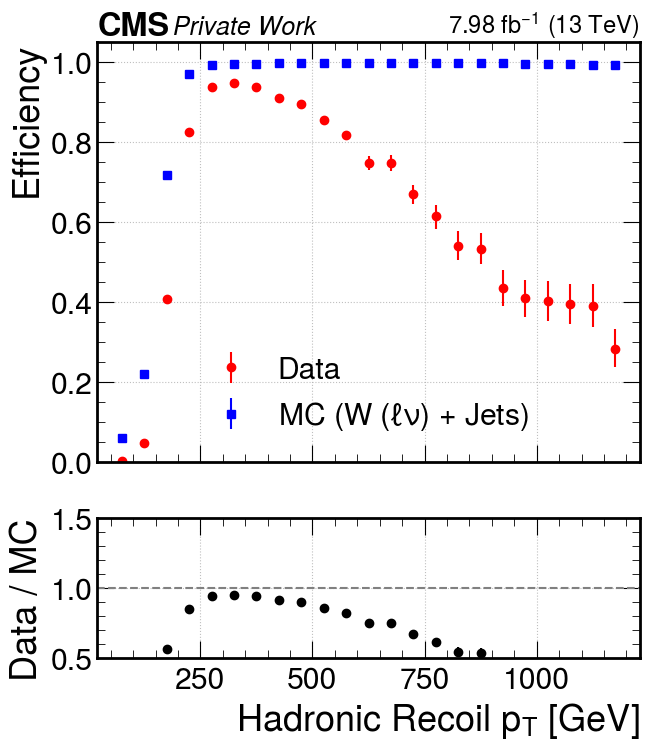

In [20]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = num_bkg.axes[vari].centers
mask = (den_bkg.values() > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# --- Efficiency ---
ax1.errorbar(
    x[mask], eff_data[mask], yerr=[np.abs(eff_data[mask] - data_err_low[mask]), np.abs(eff_data[mask] - data_err_up[mask])],
    fmt='o', label='Data', color='red',
)
ax1.errorbar(
    x[mask], eff_mc[mask], yerr=err_mc[mask],
    fmt='s', label=f'MC ({dataset_mc})', color='blue',
)
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True)

# --- Scale Factor ---
ax2.errorbar(
    x[mask], sf[mask], yerr=sf_err,#[mask],
    fmt='o', color='black'
)

print(err_mc)
ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel("Data / MC")
ax2.set_xlabel(f"{vari_name[vari]}")
ax2.set_ylim(0.5, 1.5)
ax2.grid(True)

#ax2.set_xlabel("Recoil $p_T$ [GeV]")
plt.show()
fig.savefig('./plots_recoiltrg/'+whathist[histversion]+'_'+vari+year+'_'+region+'_fillnone.png')

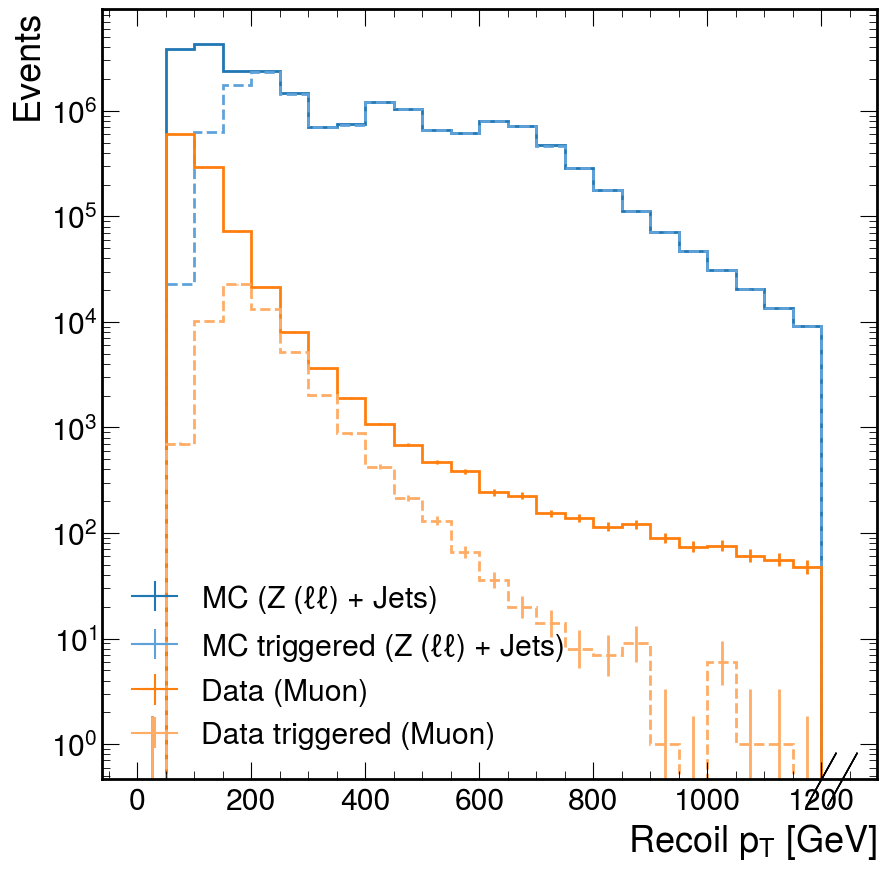

In [20]:
import matplotlib.pyplot as plt
import mplhep as hep

vari = 'recoilpt'
region = 'dimu'
if region == 'dimu':
    dataset_mc = 'Z ($\\ell\\ell$) + Jets'
if region == 'muon':
    dataset_mc = 'W ($\\ell\\nu$) + Jets'
dataset_dt = 'Muon'

PF1_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

PF1_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

num_bkg  = (PF1_bkg + PF2_bkg + PF3_bkg)# + PF4_bkg)
num_data = (PF1_data + PF2_data + PF3_data)# + PF4_data)
#num_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)#.values()
den_data = hists['data'][vari][dataset_dt][{'region':region,'IsoMu':1}].project(vari)#.values()
den_bkg = hists['bkg'][vari][dataset_mc][{'region':region,'IsoMu':1}].project(vari)#.values()

pure_data = hists['data'][vari][dataset_dt][{'region':region}].project(vari)
pure_bkg  = hists['bkg'][vari][dataset_mc][{'region':region}].project(vari)

hep.style.use("CMS")

fig, ax = plt.subplots()
#youout = '''
hep.histplot(
    den_bkg,
    ax=ax,
    label=f"MC ({dataset_mc})",
    linewidth=2,
    color="#1f77b4"
)

hep.histplot(
    num_bkg,
    ax=ax,
    label=f"MC triggered ({dataset_mc})",
    linewidth=2,
    color="#5fa2d9",
    linestyle='--'
)
#'''
hep.histplot(
    den_data,
    ax=ax,
    label="Data (Muon)",
    linewidth=2,
    color="#ff7f0e"
)
#b = '''
hep.histplot(
    num_data,
    ax=ax,
    label="Data triggered (Muon) ",
    linewidth=2,
    color="#ffad66",
    linestyle='--'
)
#'''
ax.set_xlabel("Recoil $p_T$ [GeV]")
ax.set_ylabel("Events")
ax.legend()
ax.set_yscale('log')

plt.show()
#fig.savefig('./plots_recoiltrg/'+region+'_'+whathist[histversion]+'_'+vari+year+'dist_moreCUTs_log.png')

## Data or MC only plots

In [46]:
hists = load('./hadmonotoprecoiltrg4_fill0.scaled')

year = '2022'
region = 'muon'
only = 'data'
#dataset_mc = 'Z ($\\ell\\ell$) + Jets'
if only == 'bkg':
    dataset_one = 'W ($\\ell\\nu$) + Jets'
else:
    dataset_one = 'Muon'
vari = 'recoilpt'
PF1_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

num_one = PF1_one + PF2_one + PF3_one# + PF4_data
den_one = PF1_one + PF2_one + PF3_one + PF4_one 

In [47]:
one_err_low, one_err_up = ClopperPearson(den_one.values(), num_one.values(), level=0.68)


eff_one, err_one = efficiency(num_one, den_one)


In [48]:
binedges = den_one.axes["recoilpt"].edges
print("%3s  low edge" % str("bin"), "%9s" % str("num"), "%9s" % str("den") )
for i in range(len(den_one.values())):
    print("%3s" % i, "%9s" % binedges[i], "%9s" % list(num_one.values())[i], "%9s" % list(den_one.values())[i] )

bin  low edge       num       den
  0       0.0       0.0       0.0
  1      50.0     580.0  330222.0
  2     100.0   10751.0  229898.0
  3     150.0   71078.0  174822.0
  4     200.0   66747.0   80809.0
  5     250.0   34539.0   36854.0
  6     300.0   16914.0   17856.0
  7     350.0    8670.0    9246.0
  8     400.0    4539.0    4991.0
  9     450.0    2601.0    2905.0
 10     500.0    1496.0    1748.0
 11     550.0    1001.0    1224.0
 12     600.0     552.0     738.0
 13     650.0     402.0     537.0
 14     700.0     286.0     427.0
 15     750.0     183.0     298.0
 16     800.0     112.0     207.0
 17     850.0     103.0     193.0
 18     900.0      61.0     140.0
 19     950.0      54.0     132.0
 20    1000.0      45.0     112.0
 21    1050.0      43.0     109.0
 22    1100.0      39.0     100.0
 23    1150.0      32.0     113.0


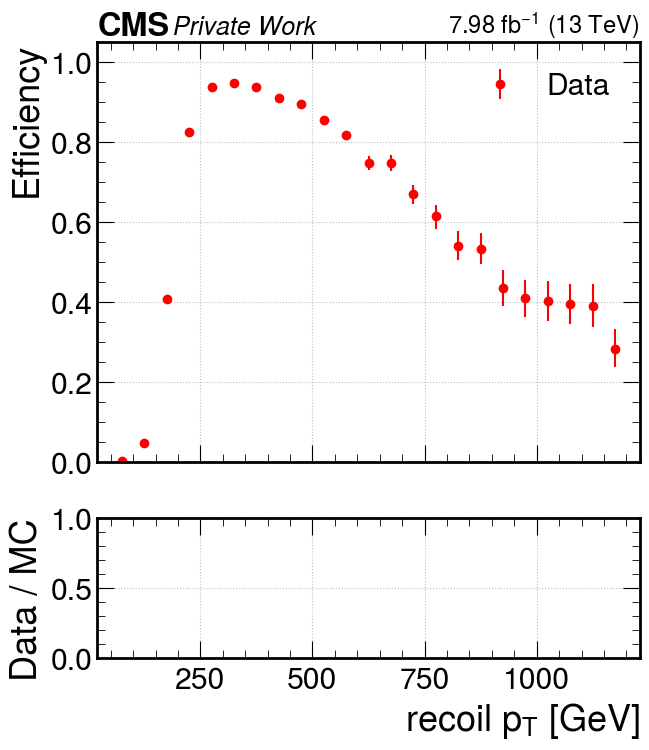

In [49]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = num_one.axes[vari].centers
mask = (den_one.values() > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# --- Efficiency ---
ax1.errorbar(
    x[mask], eff_one[mask], yerr=[np.abs(eff_one[mask] - one_err_low[mask]), np.abs(eff_one[mask] - one_err_up[mask])],
    fmt='o', label='Data', color='red',
)
#ax1.errorbar(
#    x[mask], eff_mc[mask], yerr=err_mc[mask],
#    fmt='s', label=f'MC ({dataset_mc})', color='blue',
#)
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True)

# --- Scale Factor ---
#ax2.errorbar(
#    x[mask], sf[mask], yerr=sf_err,#[mask],
#    fmt='o', color='black'
#)

ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel("Data / MC")
ax2.set_xlabel("recoil $p_T$ [GeV]")
#ax2.set_ylim(0.95, 1.05)
ax2.grid(True)

#ax2.set_xlabel("Recoil $p_T$ [GeV]")
plt.show()
#fig.savefig('./plots_recoiltrg/eleTrgEff_'+region+'_'+whathist[histversion]+'_'+vari+year+'_data.png')

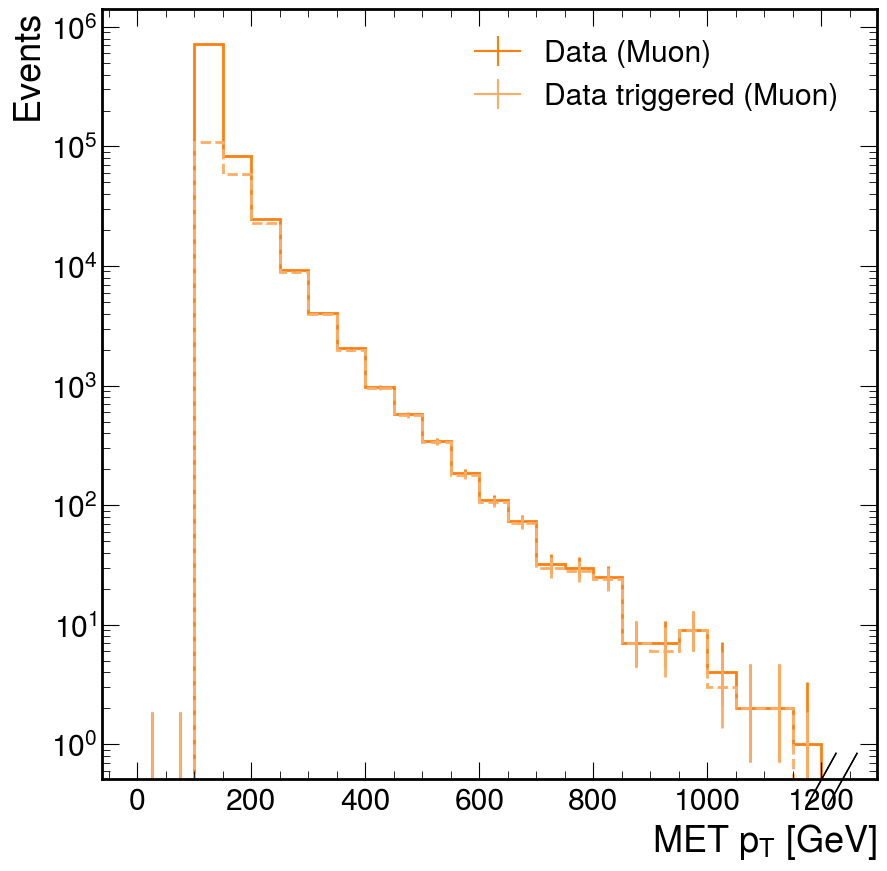

In [92]:
import matplotlib.pyplot as plt
import mplhep as hep

vari = 'metpt'
region = 'muon'

PF1_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':0}].project(vari)
PF2_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':1}].project(vari)
PF3_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':1, 'PFMETNoMu120PFHT60':1}].project(vari)
PF4_one = hists[only][vari][dataset_one][{'region':region,'IsoMu':1, 'PFMETNoMu120':0, 'PFMETNoMu120PFHT60':0}].project(vari)

num_one = PF1_one + PF2_one + PF3_one# + PF4_data
den_one = PF1_one + PF2_one + PF3_one + PF4_one 
hep.style.use("CMS")

fig, ax = plt.subplots()
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

hep.histplot(
    den_one,
    ax=ax,
    label="Data (Muon)",
    linewidth=2,
    color="#ff7f0e"
)
#b = '''
hep.histplot(
    num_one,
    ax=ax,
    label="Data triggered (Muon) ",
    linewidth=2,
    color="#ffad66",
    linestyle='--'
)

#'''
ax.set_xlabel("MET $p_T$ [GeV]")
ax.set_ylabel("Events")
ax.legend()
ax.set_yscale('log')

plt.show()
fig.savefig('./plots_recoiltrg/'+region+'_'+whathist[histversion]+'_'+vari+year+'dist_moreREF_data_log.png')

## Fixed DATA recoil trigger efficiency

In [230]:
import uproot
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
import os, sys


In [231]:
year = '22post'
lumi = {
    '22pre' : 7.98,
    '22post': 26.67,
    '23pre': 17.794,
    '23post': 9.451
}
r1 = uproot.open(f"/home/jieun/working/monotopRun3/recoil_trigger_eff_{year}.root")
r2 = uproot.open(f"/mnt/mydisk/work2T/run3Monotop/RecoilTrigEff/recoil_trigger_eff_{year}_mc.root")

In [232]:
## DATA
h1 = r1["recoil_efficiency;1"]
values = h1.values()
edges = h1.axis().edges()
centers = 0.5 * (edges[:-1] + edges[1:])
h_triggered = r1["triggered;1"]
h_total     = r1["total;1"]
triggered = h_triggered.values()
total     = h_total.values()

In [233]:
## MC
h2 = r2["recoil_efficiency;1"]
values_mc = h2.values()
edges_mc = h2.axis().edges()
centers_mc = 0.5 * (edges_mc[:-1] + edges_mc[1:])
h_triggered_mc = r2["triggered;1"]
h_total_mc     = r2["total;1"]
triggered_mc = h_triggered_mc.values()
total_mc     = h_total_mc.values()

In [234]:
data_err_low, data_err_up = ClopperPearson(h_total.values(), h_triggered.values(), level=0.68)
eff_data, err_data = efficiency(h_triggered, h_total)

In [235]:
mc_err_low, mc_err_up = ClopperPearson(h_total_mc.values(), h_triggered_mc.values(), level=0.68)
eff_mc, err_mc = efficiency(h_triggered_mc, h_total_mc)

In [236]:
sf = np.divide(
    eff_data, eff_mc,
    out=np.zeros_like(eff_data),
    where=eff_mc > 0
)

In [237]:
sf

array([0.        , 0.        , 0.        , 0.03416036, 0.07334701,
       0.16272061, 0.31393599, 0.46327638, 0.60012646, 0.72312811,
       0.82472769, 0.90223047, 0.94979855, 0.97518748, 0.98683349,
       0.9928211 , 0.99494781, 0.99696059, 0.99891221, 0.99899719,
       0.9979893 , 0.99836043, 1.0008548 , 1.00013891, 0.9998426 ,
       1.00135867, 0.99999421, 0.99970956, 0.99911423, 1.00115688,
       1.00104267, 0.99737986, 1.00106081, 0.99555455, 1.00119307,
       1.00115831, 1.0012617 , 0.97223215, 0.98357825, 1.00140455,
       1.0013565 , 0.98247347, 0.97439856, 1.00136995, 1.00130322,
       1.00150915, 1.00156913, 1.00156184, 1.00176454, 1.00135557])

In [238]:
sf_err = np.zeros_like(sf)

mask = (eff_mc > 0) & (eff_data > 0)
print(err_data)
print(eff_data)
sf_err[mask] = sf[mask] * np.sqrt(
    (err_data[mask] / eff_data[mask])**2 +
    (err_mc[mask]   / eff_mc[mask])**2
)
sf_err

[0.00000000e+00 0.00000000e+00 0.00000000e+00 1.22551916e-05
 2.30423550e-05 1.36907950e-04 4.77589836e-04 8.67122838e-04
 1.22874615e-03 1.41980739e-03 1.42777638e-03 1.31612719e-03
 1.15644983e-03 9.97986823e-04 8.82688413e-04 8.07633886e-04
 8.23816041e-04 7.89672865e-04 6.89970239e-04 7.47861154e-04
 9.70332457e-04 1.05459271e-03 4.86026688e-04 8.78938932e-04
 1.12328215e-03 0.00000000e+00 1.33779174e-03 1.58102618e-03
 2.07683983e-03 0.00000000e+00 0.00000000e+00 3.72437532e-03
 0.00000000e+00 5.54010196e-03 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.01966232e-02 1.76969859e-02 0.00000000e+00
 0.00000000e+00 1.86890776e-02 2.66592952e-02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 8.57900210e-05
 3.64398022e-04 5.86916296e-03 5.69423738e-02 2.00397915e-01
 4.18411158e-01 6.34049503e-01 7.90128465e-01 8.87931485e-01
 9.42284520e-01 9.70588235e-01 9.83515955e-01 9.90025

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.25398737e-03,
       5.05543737e-03, 4.00436981e-03, 2.72456659e-03, 2.05659129e-03,
       1.79568836e-03, 1.63742482e-03, 1.49835242e-03, 1.34140343e-03,
       1.16859641e-03, 1.00538252e-03, 8.88538144e-04, 8.13374608e-04,
       8.29811433e-04, 7.95050350e-04, 6.95139481e-04, 7.51740736e-04,
       9.73132947e-04, 1.05725312e-03, 4.89407513e-04, 8.81902524e-04,
       1.12658066e-03, 6.59501231e-05, 1.34143598e-03, 1.58473063e-03,
       2.08045413e-03, 6.35284819e-05, 5.62465070e-05, 3.72894480e-03,
       5.43758382e-05, 5.54658300e-03, 6.35386524e-05, 6.77085694e-05,
       7.68330368e-05, 2.02221138e-02, 1.77231157e-02, 1.05946297e-04,
       1.13513524e-04, 1.87150237e-02, 2.66987059e-02, 1.46974552e-04,
       1.55866369e-04, 1.81817753e-04, 2.01064307e-04, 2.16757724e-04,
       2.49763681e-04, 2.36134362e-04])

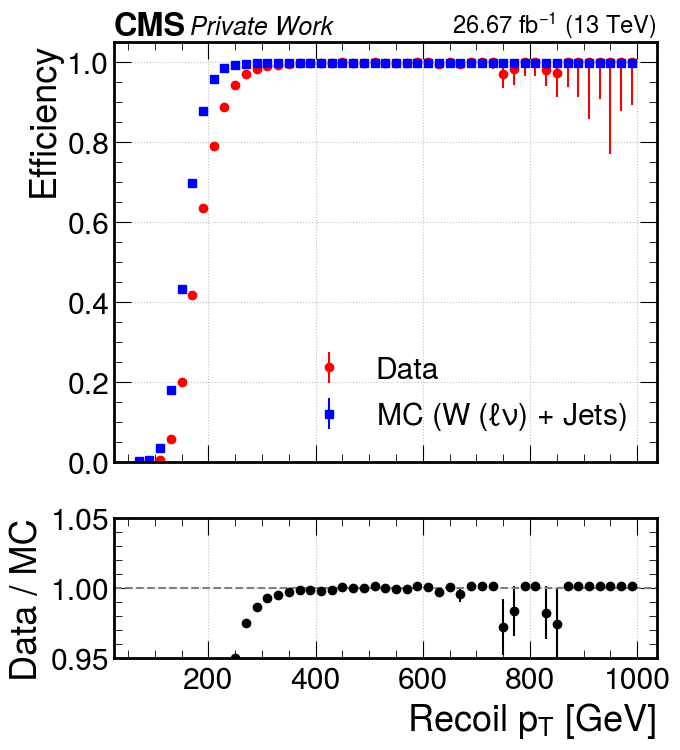

In [244]:
import matplotlib.pyplot as plt
import mplhep as hep

hep.style.use("CMS")

x = centers
mask = (h_total.values() > 0)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,8),
    sharex=True,
    gridspec_kw={"height_ratios": [3,1]}
)

# --- Efficiency ---
ax1.errorbar(
    x[mask], eff_data[mask], yerr=[np.abs(eff_data[mask] - data_err_low[mask]), np.abs(eff_data[mask] - data_err_up[mask])],
    fmt='o', label='Data', color='red',
)
ax1.errorbar(
#    x[mask], eff_mc[mask], yerr=err_mc[mask],
    x[mask], eff_mc[mask], yerr=[np.abs(eff_mc[mask] - mc_err_low[mask]), np.abs(eff_mc[mask] - mc_err_up[mask])],
    fmt='s', label=f'MC ({dataset_mc})', color='blue',
)
hep.cms.label(ax=ax1, llabel='Private Work', rlabel=str(lumi[year])+' fb$^{-1}$ (13 TeV)', fontsize=18)

ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True)

# --- Scale Factor ---
ax2.errorbar(
    x[mask], sf[mask], yerr=sf_err[mask],
    fmt='o', color='black'
)

ax2.axhline(1.0, color='gray', linestyle='--')
ax2.set_ylabel("Data / MC")
ax2.set_xlabel("Recoil $p_T$ [GeV]")
ax2.set_ylim(0.95, 1.05)
ax2.grid(True)

#ax2.set_xlabel("Recoil $p_T$ [GeV]")
plt.show()
#fig.savefig('./plots_recoiltrg/RecoilTrgEff_'+year+'_2.png')

In [74]:
for x, y in zip(centers, values):
    print(f"x={x:.2f}, y={y:.4f}")
    break


x=10.00, y=0.0000
[0.         0.         0.         0.00926229 0.01908921 0.07661046
 0.23862601 0.44765826 0.64684709 0.79627225 0.88889171 0.94230116
 0.97071341 0.98518437 0.99172373 0.99500038 0.9962032  0.99746216
 0.99853313 0.99870214 0.99831508 0.99850523 0.9997569  0.99937792
 0.99920477 1.         0.99933043 0.99920855 0.99895996 1.
 1.         0.99813258 1.         0.99721835 1.         1.
 1.         0.98540068 0.99103121 1.         1.         0.99052111
 0.98639392 1.         1.         1.         1.         1.
 1.         1.        ]


## Save as JSON file for correlctionlib

In [239]:
import json
corr = {
    "schema_version": 2,
    "corrections": [
        {
            "name": f"recoil_trigger_sf_{year}",
            "version": 1,
            "inputs": [
                {"name": "ut", "type": "real"},
                {"name": "variation", "type": "string"}
            ],
            "output": {"name": "weight", "type": "real"},
            "data": {
                "nodetype": "category",
                "input": "variation",
                "content": [
                    {
                        "key": "nominal",
                        "value": {
                            "nodetype": "binning",
                            "input": "ut",
                            "edges": edges.tolist(),
                            "content": sf.tolist(),
                            "flow": "clamp"
                        },
                    },
                    {
                        "key": "up",
                        "value": {
                            "nodetype": "binning",
                            "input": "ut",
                            "edges": edges.tolist(),
                            "content": (sf + sf_err).tolist(),
                            "flow": "clamp"
                        },
                    },
                    {
                        "key": "down",
                        "value": {
                            "nodetype": "binning",
                            "input": "ut",
                            "edges": edges.tolist(),
                            "content": (sf - sf_err).tolist(),
                            "flow": "clamp"
                        },
                    },
                ],
            },
        }
    ],
}
with open(f"/home/jieun/working/work2T/run3Monotop/RecoilTrigEff/recoil_trigger_sf_{year}.json", "w") as f:
    json.dump(corr, f, indent=2)

In [248]:
from correctionlib import CorrectionSet

cset = CorrectionSet.from_file(f"/home/jieun/working/work2T/run3Monotop/RecoilTrigEff/recoil_trigger_sf_{year}.json.gz")
corr = cset[f"recoil_trigger_sf_22post"]

ut_value = [351., 432.1, 0, 456., 15001]

weight = corr.evaluate(ut_value, "nominal")
weight_up = corr.evaluate(ut_value, "up")
weight_down = corr.evaluate(ut_value, "down")
print(weight)

[0.99696059 0.99836043 0.         1.0008548  1.00135557]


In [225]:
for corr in cset.values():
    print(corr.name)
    print(cset['recoil_trigger_sf_22pre'])

recoil_trigger_sf_22pre


In [ ]:
def get_met_trig_weight(year, met):
    corrname = { 
        '2022pre' : "recoil_trigger_sf_22pre",
        '2022post': "recoil_trigger_sf_22post",
        '2023pre' : "recoil_trigger_sf_23pre",
        '2023post': "recoil_trigger_sf_23post"
    }    
    cset = CorrectionSet.from_file(f"data/METTrigEff/recoil_trigger_sf_{year}.json.gz")
    corr = cset[corrname[year]]

    met  = ak.fill_none(met, 0.) 
    #met  = ak.where((met>950.), ak.full_like(met,950.), met) 

    weight = corr.evaluate(met, "nominal")
    weight_up   = corr.evaluate(met, "up")
    weight_down = corr.evaluate(met, "down")

    return weight, weight_up, weight_down    


In [ ]:
met_nom, met_up, met_down = get_met_trig_weight('2022pre', met.pt)                                                                                     
print('met nominal wieght', met_nom)